In [ ]:
import glob

import torch
from librosa import load

from ddsp.feature_extractors import LibrosaFeatureExtractor

dataset_path = '/mnt/mariadata/datasets/noise-artists/hecker/processed'
dataset_files = glob.glob(f'{dataset_path}/*.wav')

def normalize_feature(feature: torch.Tensor) -> torch.Tensor:
  """Normalizes the feature to the range [0, 1]."""
  return (feature - feature.min()) / (feature.max() - feature.min())

def smoothen_feature(feature: torch.Tensor, window_size: int = 2048*4+1) -> torch.Tensor:
  """Smoothens the feature using a simple moving average."""
  return torch.nn.functional.avg_pool1d(feature, kernel_size=window_size, stride=1, padding=window_size // 2)

def process_feature(feature: torch.Tensor) -> torch.Tensor:
  """Processes the feature by normalizing and smoothening it."""
  feature = smoothen_feature(feature)
  feature = normalize_feature(feature)
  return feature


In [7]:
idx = 1
audio, sr = load(dataset_files[idx], sr=None)
audio = torch.tensor(audio).unsqueeze(0)

chunk_dur = sr * 8
# Chunk the audio to the central
if audio.shape[-1] > chunk_dur:
  audio = audio[:, (audio.shape[-1]//2 - chunk_dur//2):(audio.shape[-1]//2 + (chunk_dur//2+1))]

extractors = {
  'spectral_centroid': LibrosaFeatureExtractor(LibrosaFeatureExtractor.FN_SPECTRAL_CENTROID, resampling_factor=1),
  'loudness': LibrosaFeatureExtractor(LibrosaFeatureExtractor.FN_LOUDNESS, resampling_factor=1),
  'spectral_flatness': LibrosaFeatureExtractor(LibrosaFeatureExtractor.FN_SPECTRAL_FLATNESS, resampling_factor=1),
  'spectral_bandwidth': LibrosaFeatureExtractor(LibrosaFeatureExtractor.FN_SPECTRAL_BANDWIDTH, resampling_factor=1),
}

features = {}
for feature_name, extractor in extractors.items():
  feature = extractor(audio)
  feature = process_feature(feature)
  features[feature_name] = feature


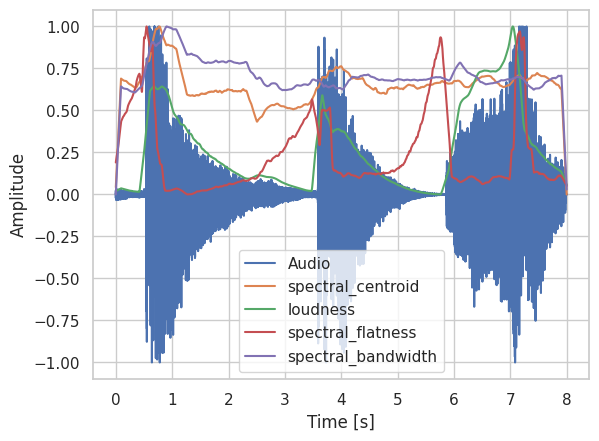

In [8]:
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")

x_time = np.arange(audio.shape[-1]) / sr
plt.plot(x_time, audio.squeeze().numpy(), label='Audio')
for feature_name, feature in features.items():
  plt.plot(x_time, feature.squeeze().numpy(), label=feature_name)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

display(Audio(audio, rate=sr))